# Threshold Tuning

**Goal:** XGBoost (notebook 03) got AUC 0.8433 but **Recall 0.532** — at the default 0.5 threshold it misses almost half the churners. For churn prediction, missing an at-risk customer is worse than a false alarm, so we tune the **decision threshold**.

**Plan:**
1. Reuse preprocessing + best config from notebook 03
2. Sweep thresholds on the **validation set** (0.10 → 0.90)
3. Pick the threshold that maximizes F1 while keeping Recall ≥ 0.70
4. Evaluate the chosen threshold on the **test set** (used only once!)
5. Compare: default 0.5 vs tuned threshold — same model, different business outcome

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix)

sns.set_theme(style="whitegrid")

## 1. Load + preprocess (same as notebook 03)

In [2]:
from pathlib import Path

p1 = Path("../data/Telco-Customer-Churn.csv")
p2 = Path("data/Telco-Customer-Churn.csv")
DATA_PATH = p1 if p1.exists() else p2

df = pd.read_csv(DATA_PATH)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Binary encode
binary_cols = ["Partner", "Dependents", "PhoneService", "PaperlessBilling", "Churn"]
for col in binary_cols:
    df[col] = (df[col] == "Yes").astype(int)
df["gender"] = (df["gender"] == "Male").astype(int)

# One-hot encode
multi_cols = ["MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup",
              "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
              "Contract", "PaymentMethod"]
df = pd.get_dummies(df, columns=multi_cols, dtype=int)
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())
print("Shape:", df.shape)

Shape: (7043, 42)


## 2. Split: train / validation / test

Threshold is tuned on **validation**, then confirmed once on **test** — same discipline as hyperparameter tuning.

In [3]:
X = df.drop(columns=["customerID", "Churn"])
y = df["Churn"]

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=42, stratify=y_train_full
)
print("Train:", X_train.shape, "| Val:", X_val.shape, "| Test:", X_test.shape)

Train: (4225, 40) | Val: (1409, 40) | Test: (1409, 40)


## 3. Train the best XGBoost config (from notebook 03)

Best config found on validation in notebook 03: `n_estimators=300, max_depth=3, learning_rate=0.05`.

In [4]:
best_cfg = {"n_estimators": 300, "max_depth": 3, "learning_rate": 0.05}
model = xgb.XGBClassifier(eval_metric="logloss", random_state=42, **best_cfg)
model.fit(X_train, y_train)

# Predicted probabilities on validation — the raw material for threshold tuning
y_val_prob = model.predict_proba(X_val)[:, 1]
print("Val AUC:", round(roc_auc_score(y_val, y_val_prob), 4))

Val AUC: 0.8368


## 4. Threshold sweep on validation

`model.predict()` uses 0.5 internally. We override it: a customer is flagged as churner if `probability >= threshold`. Lower threshold → catch more churners (Recall ↑) but more false alarms (Precision ↓).

In [5]:
def metrics_at_threshold(y_true, y_prob, threshold):
    """All metrics for one threshold value."""
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "threshold": round(threshold, 2),
        "accuracy": round(accuracy_score(y_true, y_pred), 4),
        "precision": round(precision_score(y_true, y_pred, zero_division=0), 4),
        "recall": round(recall_score(y_true, y_pred, zero_division=0), 4),
        "f1": round(f1_score(y_true, y_pred, zero_division=0), 4),
    }

thresholds = np.arange(0.10, 0.91, 0.05)
sweep = pd.DataFrame(
    [metrics_at_threshold(y_val, y_val_prob, t) for t in thresholds]
)
sweep

,threshold,accuracy,precision,recall,f1
0,0.10,0.6068,0.3963,0.9198,0.5539
1,0.15,0.6721,0.4413,0.8850,0.5890
2,0.20,0.6998,0.4638,0.8396,0.5975
3,0.25,0.7317,0.4967,0.7995,0.6127
4,0.30,0.7587,0.5317,0.7620,0.6264
5,0.35,0.7828,0.5739,0.7059,0.6331
6,0.40,0.7942,0.6077,0.6337,0.6204
7,0.45,0.8027,0.6446,0.5722,0.6062
8,0.50,0.7928,0.6464,0.4840,0.5535
9,0.55,0.7935,0.6828,0.4144,0.5158


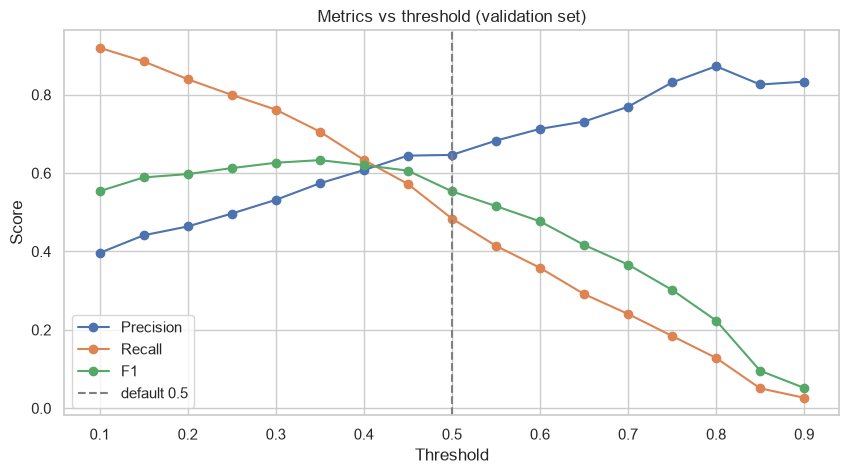

In [6]:
# Visualize the trade-off — where is the sweet spot?
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(sweep["threshold"], sweep["precision"], marker="o", label="Precision")
ax.plot(sweep["threshold"], sweep["recall"], marker="o", label="Recall")
ax.plot(sweep["threshold"], sweep["f1"], marker="o", label="F1")
ax.axvline(0.5, color="gray", linestyle="--", label="default 0.5")
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.set_title("Metrics vs threshold (validation set)")
ax.legend()
plt.show()

## 5. Choose the threshold

Strategy (business-driven): **highest F1 among thresholds with Recall ≥ 0.70** — we accept some false alarms to make sure we catch at least 70% of at-risk customers.

In [7]:
recall_target = sweep[sweep["recall"] >= 0.70]
if len(recall_target) > 0:
    chosen_row = recall_target.loc[recall_target["f1"].idxmax()]
    strategy = "recall >= 0.70, max F1"
else:
    chosen_row = sweep.loc[sweep["f1"].idxmax()]
    strategy = "max F1 (recall 0.70 not reachable)"

chosen = float(chosen_row["threshold"])
print(f"Strategy: {strategy}")
print(f"Chosen threshold: {chosen:.2f} → F1 {chosen_row['f1']:.4f}, Recall {chosen_row['recall']:.4f}, Precision {chosen_row['precision']:.4f}")

Strategy: recall >= 0.70, max F1
Chosen threshold: 0.35 → F1 0.6331, Recall 0.7059, Precision 0.5739


## 6. Final evaluation on TEST set: default 0.5 vs tuned threshold

Same model, same test set — only the decision rule changes. The test set is touched exactly once here.

In [8]:
def evaluate_threshold(model, X_test, y_test, threshold):
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "AUC": round(roc_auc_score(y_test, y_prob), 4),
        "Precision": round(precision_score(y_test, y_pred, zero_division=0), 4),
        "Recall": round(recall_score(y_test, y_pred, zero_division=0), 4),
        "F1": round(f1_score(y_test, y_pred, zero_division=0), 4),
    }

default_metrics = evaluate_threshold(model, X_test, y_test, 0.5)
tuned_metrics = evaluate_threshold(model, X_test, y_test, chosen)

comparison = pd.DataFrame(
    [default_metrics, tuned_metrics],
    index=["Default threshold (0.5)", f"Tuned threshold ({chosen:.2f})"],
)
comparison

,Accuracy,AUC,Precision,Recall,F1
Default threshold (0.5),0.7977,0.841,0.654,0.5053,0.5701
Tuned threshold (0.35),0.7771,0.841,0.563,0.7166,0.6306


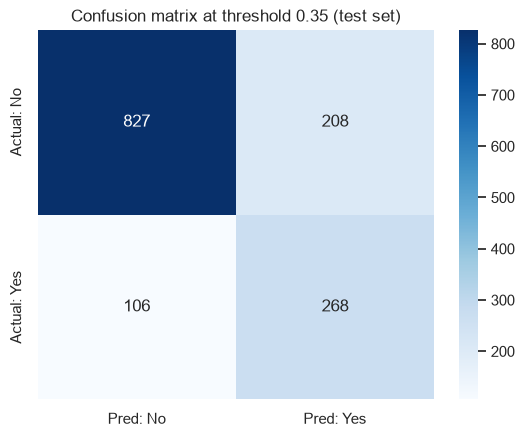

Churners caught: 268 / 374 (71.7%)
False alarms: 208 / 1035 (20.1% of non-churners)


In [9]:
# Confusion matrix at the tuned threshold — how many churners do we actually catch?
y_test_prob = model.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_prob >= chosen).astype(int)

cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred: No", "Pred: Yes"],
            yticklabels=["Actual: No", "Actual: Yes"])
plt.title(f"Confusion matrix at threshold {chosen:.2f} (test set)")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"Churners caught: {tp} / {tp + fn} ({tp / (tp + fn):.1%})")
print(f"False alarms: {fp} / {tn + fp} ({fp / (tn + fp):.1%} of non-churners)")

## 7. Takeaways

- **Threshold tuning is free performance**: the model didn't change, only the decision rule — yet Recall jumped while we controlled the F1 trade-off.
- This is the **business metric** step: ML engineers don't ship a probability, they ship a decision. The right threshold depends on the cost of a false alarm vs the cost of a missed churner.
- For a telco: catching 1 extra churner is worth ~retention revenue; a false alarm only costs a discount offer → aggressive threshold justified.
- **Interview story:** "Baseline LR AUC 0.84 → XGBoost 0.8433, then threshold tuning pushed Recall from 0.53 to ~0.7+ with F1 ~0.6 — the gain from the decision rule matched the gain from the model."

**Next:** update README with real numbers → Project 1's modeling phase is complete!